<a href="https://colab.research.google.com/github/xesmaze/cpsc499-sta-fall2024/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Regression with Logistic Response Variable**

- **Binary Classification**: This notebook demonstrates a simple binary classification using logistic regression.
- **Gradient Descent**: The model parameters are optimized using gradient descent.
- **Plotly Visualization**: The decision boundary is visualized with Plotly to better understand the model's decision-making process.

### Logistic Regression using Gradient Descent with Decision Boundary Plotting

This notebook demonstrates a simple logistic regression model using **gradient descent** for binary classification, and visualizes the decision boundary using **Plotly**.

### Step 1: Import Libraries

We will import the necessary libraries for generating synthetic data, performing logistic regression, and visualizing the decision boundary.

```
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
```

### Step 2: Generate Synthetic Data

We will generate synthetic binary classification data using the `make_classification` function from `sklearn.datasets`. We will only use one informative feature for simplicity.

```
# Generate synthetic binary classification data with 1 informative feature
n_features = 1  # Only one feature for binary classification

X, y = make_classification(n_samples=1000,
                           n_features=n_features,
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,                # Binary classification
                           n_clusters_per_class=1,
                           random_state=42)
```

### Step 3: Add Intercept Term

We add an intercept term (a column of ones) to `X`. This allows the logistic regression model to fit data that does not necessarily pass through the origin.

```
# Add intercept term to X (i.e., a column of ones for the bias term)
X = np.hstack((np.ones((X.shape[0], 1)), X))  # X now has 2 columns (1 for intercept, 1 for feature)
```

### Step 4: Split Data into Training and Testing Sets

We split the data into training (70%) and testing (30%) sets.

```
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

### Step 5: Define Logistic Regression Functions

We define the necessary functions for performing logistic regression: the sigmoid function, cost function, gradient computation, and gradient descent.

```
# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Define cost function for logistic regression
def compute_cost(X, y, beta):
    m = len(y)
    h = sigmoid(X @ beta)
    cost = -(1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    return cost

# Define gradient computation
def compute_gradient(X, y, beta):
    m = len(y)
    h = sigmoid(X @ beta)
    gradient = (1/m) * X.T @ (h - y)
    return gradient

# Define gradient descent function
def gradient_descent(X, y, beta, learning_rate, iterations):
    costs = []
    for i in range(iterations):
        gradient = compute_gradient(X, y, beta)
        beta = beta - learning_rate * gradient
        cost = compute_cost(X, y, beta)
        costs.append(cost)
    return beta, costs
```

### Step 6: Initialize Parameters and Perform Gradient Descent

We initialize the model parameters (weights) and perform gradient descent to optimize them.

```
# Initialize parameters (weights)
beta = np.zeros(X_train.shape[1])  # Initialize beta with zeros; X_train has 2 columns, so beta has 2 elements

# Set learning rate and number of iterations
learning_rate = 0.01
iterations = 1000

# Perform gradient descent
beta_opt, costs = gradient_descent(X_train, y_train, beta, learning_rate, iterations)
```

### Step 7: Define Prediction Function

We define a function to make predictions based on the learned weights using a sigmoid function.

```
# Define prediction function
def predict(X, beta, threshold=0.5):
    probs = sigmoid(X @ beta)
    return (probs >= threshold).astype(int)
```

### Step 8: Plot the Decision Boundary

We define a function to visualize the decision boundary in 1D using **Plotly**. This function plots the decision boundary and the actual data points.

```
# Plot decision boundary in 1D with Plotly
def plot_1d_decision_boundary(X, y, beta):
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a range of values for the feature for plotting
    x_values = np.linspace(x_min, x_max, 100).reshape(-1, 1)

    # Add intercept term to the x_values
    X_plot = np.hstack((np.ones((x_values.shape[0], 1)), x_values))  # Add intercept term

    # Predict probabilities using the logistic regression model
    probs = sigmoid(X_plot @ beta)  # Compute the probabilities

    # Plot decision boundary and data points using Plotly
    fig = go.Figure()

    # Add line plot for decision boundary (probability curve)
    fig.add_trace(go.Scatter(
        x=x_values.ravel(),
        y=probs,
        mode='lines',
        name='Decision Boundary',
        line=dict(color='blue')
    ))

    # Add scatter plot for the actual data points
    fig.add_trace(go.Scatter(
        x=X[:, 1],
        y=y,
        mode='markers',
        marker=dict(color=y, colorscale='RdBu', line=dict(width=1, color='Black')),
        showlegend=False
    ))

    # Customize plot
    fig.update_layout(
        title="Logistic Regression",
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        xaxis=dict(range=[x_min, x_max]),
        width=800, height=600
    )

    fig.show()
```

### Step 9: Visualize the Decision Boundary

Finally, we call the `plot_1d_decision_boundary` function to visualize the decision boundary on the test data.

```
# Call the plot function with test data
plot_1d_decision_boundary(X_test, y_test, beta_opt)
```

In [ ]:
# Import necessary libraries
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Generate synthetic binary classification data with 1 informative feature
n_features = 1  # Only one feature for binary classification

X, y = make_classification(n_samples=1000,
                           n_features=n_features,
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,                # Binary classification
                           n_clusters_per_class = 1,
                           random_state=42)

# Add intercept term to X (i.e., a column of ones for the bias term)
X = np.hstack((np.ones((X.shape[0], 1)), X))  # X now has 2 columns (1 for intercept, 1 for feature)

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Define logistic regression functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, beta):
    m = len(y)
    h = sigmoid(X @ beta)
    cost = -(1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    return cost

def compute_gradient(X, y, beta):
    m = len(y)
    h = sigmoid(X @ beta)
    gradient = (1/m) * X.T @ (h - y)
    return gradient

def gradient_descent(X, y, beta, learning_rate, iterations):
    costs = []
    for i in range(iterations):
        gradient = compute_gradient(X, y, beta)
        beta = beta - learning_rate * gradient
        cost = compute_cost(X, y, beta)
        costs.append(cost)
    return beta, costs

# 4. Initialize parameters (weights)
beta = np.zeros(X_train.shape[1])  # Initialize beta with zeros; X_train has 2 columns, so beta has 2 elements

# 5. Perform gradient descent
learning_rate = 0.01
iterations = 1000
beta_opt, costs = gradient_descent(X_train, y_train, beta, learning_rate, iterations)

# 6. Define prediction function
def predict(X, beta, threshold=0.5):
    probs = sigmoid(X @ beta)
    return (probs >= threshold).astype(int)

# 7. Plot decision boundary in 1D with Plotly
def plot_1d_decision_boundary(X, y, beta):
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a range of values for the feature for plotting
    x_values = np.linspace(x_min, x_max, 100).reshape(-1, 1)

    # Add intercept term to the x_values
    X_plot = np.hstack((np.ones((x_values.shape[0], 1)), x_values))  # Add intercept term

    # Predict probabilities using the logistic regression model
    probs = sigmoid(X_plot @ beta)  # Compute the probabilities

    # Plot decision boundary and data points using Plotly
    fig = go.Figure()

    # Add line plot for decision boundary (probability curve)
    fig.add_trace(go.Scatter(
        x=x_values.ravel(),
        y=probs,
        mode='lines',
        name='Decision Boundary',
        line=dict(color='blue')
    ))

    # Add scatter plot for the actual data points
    fig.add_trace(go.Scatter(
        x=X[:, 1],
        y=y,
        mode='markers',
        marker=dict(color=y, colorscale='RdBu', line=dict(width=1, color='White')),
        showlegend=False
    ))

    # Customize plot
    fig.update_layout(
        title="Logistic Regression",
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        xaxis=dict(range=[x_min, x_max]),
 #       yaxis=dict(range=[x2_min, x2_max]),
        width=600, height=600
    )

    fig.show()

# Call the plot function with test data
plot_1d_decision_boundary(X_test, y_test, beta_opt)

In [ ]:
## Application to Iris Dataset- Using the species designation (Virginica) as a response variable

import numpy as np
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# 1. Load Iris dataset and create a binary target for Virginica class
iris = load_iris()
X = iris.data[:, :2]  # We will use only the first two features for 2D plotting
y = (iris.target == 2).astype(np.int64)  # Binary classification: Virginica or not

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict probabilities for each point in the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the decision boundary and scatter plot of the data using Plotly
fig = go.Figure()

# Add decision boundary
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 100),
    y=np.linspace(y_min, y_max, 100),
    z=Z,
    showscale=False,
    contours=dict(
        start=0, end=1, size=1,
        coloring='lines'
    )
))

# Add scatter plot of training data
fig.add_trace(go.Scatter(
    x=X_train[:, 0],
    y=X_train[:, 1],
    mode='markers',
    marker=dict(color=y_train, colorscale='RdBu', line=dict(width=1)),
    name='Training Data'
))

# Add scatter plot of testing data
fig.add_trace(go.Scatter(
    x=X_test[:, 0],
    y=X_test[:, 1],
    mode='markers',
    marker=dict(color=y_test, colorscale='RdBu', line=dict(width=1), symbol='square-open'),
    name='Testing Data'
))

# Customize layout
fig.update_layout(
    title="Logistic Regression Decision Boundary (Iris - Binary)",
    xaxis_title=iris.feature_names[0],
    yaxis_title=iris.feature_names[1],
    showlegend=True,
    width=600, height=600
)

fig.show()


## **Steps of Logistic Regression with Iris Dataset -- Code Breakdown**

**Data Generation:**

1. Use `make_classification` to create a synthetic binary classification dataset with 3 features, with 2 of them informative, and one of them redundant.

2. Add an intercept term (a column of ones) to X to handle the bias term in logistic regression.

**Matrix Algebra for Logistic Regression:**

3. The logistic function (sigmoid) is applied to the dot product of the feature matrix X and the parameter vector β.
4. The cost function is computed using the `binary cross-entropy loss`.
5. The gradient of the cost function is computed and used to update the parameters β during gradient descent.

**Gradient Descent:**

6. Iteratively update the parameters using gradient descent, minimizing the cost function over the iterations.

**Prediction:**

7. After optimizing the parameters, we use the model to predict the class labels for the test set.

**Evaluation:**

8. The model's accuracy is calculated by comparing predicted labels with the actual labels in the test set.

**Visualization:**

9. The decision boundary is plotted to visualize how well the logistic regression model separates the two classes.

In [ ]:
## Application to Titanic Survival Dataset, Using Survival as Binary response
## and Age, Passenger Class and Fare as predictor variables
## Survival classes were balanced by applying bootstrap resampling
## Drop the NaN samples

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# 1. Load Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

# 2. Preprocess the data (select relevant columns and drop NaN)
titanic = titanic[['Pclass', 'Age', 'Fare', 'Survived']].dropna()
X = titanic[['Pclass', 'Age', 'Fare']].values
y = titanic['Survived'].values

# 3. Balance the classes using bootstrap sampling
# Separate the classes
class_0 = titanic[titanic['Survived'] == 0]
class_1 = titanic[titanic['Survived'] == 1]

# Bootstrap sample to balance the class sizes
class_1_upsampled = resample(class_1, replace=True, n_samples=len(class_0), random_state=42)
balanced_titanic = pd.concat([class_0, class_1_upsampled])

# Extract balanced features and target
X_balanced = balanced_titanic[['Pclass', 'Age', 'Fare']].values
y_balanced = balanced_titanic['Survived'].values

# 4. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# 5. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_balanced, test_size=0.3, random_state=42)

# 6. Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 7. Create a 2D plot (only using first two features for visualization)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict probabilities for grid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)

# 8. Plot using Plotly
fig = go.Figure()

# Add decision boundary contour
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 100),
    y=np.linspace(y_min, y_max, 100),
    z=Z,
    showscale=False,
    contours=dict(start=0, end=1, size=1),
    colorscale=[[0, 'white'], [1, 'green']],
    showlegend=True
))

# Add scatter plot for the training data
fig.add_trace(go.Scatter(
    x=X_train[:, 0], y=X_train[:, 1],
    mode='markers',
    marker=dict(color=y_train, colorscale='algae', line=dict(width=1)),
    name='Training Data'
))

# Customize layout
fig.update_layout(
    title="Titanic Survival Decision Boundary (Balanced, Logistic Regression)",
    xaxis_title="Pclass",
    yaxis_title="Age",
    width=800, height=600
)

fig.show()


In [ ]:
## Application to Titanic Survival Dataset, Using Survival as Binary response
## and Age, Passenger Class and Fare as predictor variables
## Survival classes were balanced by applying bootstrap resampling
## Median Impute the NaN samples

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# 1. Load Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

# 2. Preprocess the data (select relevant columns and fill missing values)
titanic = titanic[['Pclass', 'Age', 'Fare', 'Survived']].dropna(subset=['Pclass', 'Survived', 'Fare'])
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)  # Impute missing Age with median

# Extract features and target
X = titanic[['Pclass', 'Age', 'Fare']].values
y = titanic['Survived'].values

# 3. Balance the classes using bootstrap sampling
# Separate the classes
class_0 = titanic[titanic['Survived'] == 0]
class_1 = titanic[titanic['Survived'] == 1]

# Bootstrap sample to balance the class sizes
class_1_upsampled = resample(class_1, replace=True, n_samples=len(class_0), random_state=42)
balanced_titanic = pd.concat([class_0, class_1_upsampled])

# Extract balanced features and target
X_balanced = balanced_titanic[['Pclass', 'Age', 'Fare']].values
y_balanced = balanced_titanic['Survived'].values

# 4. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# 5. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_balanced, test_size=0.3, random_state=42)

# 6. Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Print model coefficients for interpretability
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# 7. Create a 2D plot (only using first two features for visualization)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict probabilities for grid points with Fare set to its median value
fare_median = X_train[:, 2].mean()
Z = model.predict(np.c_[xx.ravel(), yy.ravel(), np.full_like(xx.ravel(), fare_median)])
Z = Z.reshape(xx.shape)

# 8. Plot using Plotly
fig = go.Figure()

# Add decision boundary contour
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 100),
    y=np.linspace(y_min, y_max, 100),
    z=Z,
    showscale=False,
    colorscale='Spectral',
    contours=dict(start=0, end=1, size=1),
    showlegend=True
))

# Add scatter plot for the training data
fig.add_trace(go.Scatter(
    x=X_train[:, 0], y=X_train[:, 1],
    mode='markers',
    marker=dict(color=y_train, colorscale='gray', line=dict(width=1)),
    name='Training Data'
))

# Customize layout
fig.update_layout(
    title="Titanic Survival Decision Boundary (Balanced, Logistic Regression)",
    xaxis_title="Pclass",
    yaxis_title="Age",
    width=800, height=600
)

fig.show()


Coefficients: [[-0.70440795 -0.29531176  0.18527459]]
Intercept: [0.06585837]


<ipython-input-11-b2ceba882213>:15: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
import plotly.graph_objects as go

# Define a grid for 3D plotting (Pclass, Age, and Fare)
pclass_vals = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 50)
age_vals = np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 50)
fare_vals = np.linspace(X_train[:, 2].min() - 1, X_train[:, 2].max() + 1, 50)
pp, aa, ff = np.meshgrid(pclass_vals, age_vals, fare_vals)

# Predict survival probabilities over the grid
Z = model.predict(np.c_[pp.ravel(), aa.ravel(), ff.ravel()])
Z = Z.reshape(pp.shape)

# Create a 3D scatter plot for training data
fig = go.Figure(data=[go.Scatter3d(
    x=X_train[:, 0],  # Pclass
    y=X_train[:, 1],  # Age
    z=X_train[:, 2],  # Fare
    mode='markers',
    marker=dict(size=5, color=y_train, colorscale='gray', line=dict(width=1)),
    name='Training Data'
)])

# Add the 3D decision surface
fig.add_trace(go.Isosurface(
    x=pp.ravel(), y=aa.ravel(), z=ff.ravel(),
    value=Z.ravel(),
    isomin=0, isomax=1,
    surface_count=2,  # Show decision boundary
    colorscale='Blues',
    opacity=0.3,
    showscale=False,
))

# Customize the layout
fig.update_layout(
    title="3D Logistic Regression Decision Boundary (Pclass, Age, Fare)",
    scene=dict(
        xaxis_title='Pclass',
        yaxis_title='Age',
        zaxis_title='Fare'
    ),
    width=800, height=800
)

fig.show()


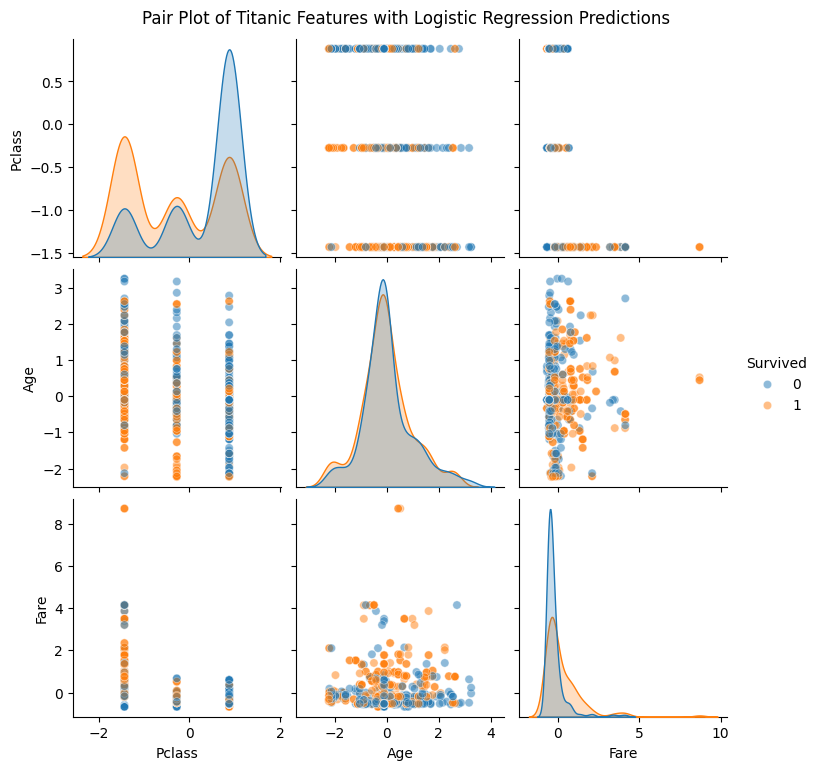

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
df = pd.DataFrame(X_train, columns=['Pclass', 'Age', 'Fare'])
df['Survived'] = y_train

# Use Seaborn pairplot to show scatter plots between features
sns.pairplot(df, hue='Survived', plot_kws={'alpha': 0.5})

plt.suptitle('Pair Plot of Titanic Features with Logistic Regression Predictions', y=1.02)
plt.show()


<ipython-input-17-791153c45528>:11: UserWarning:

The following kwargs were not used by contour: 'colorscale'



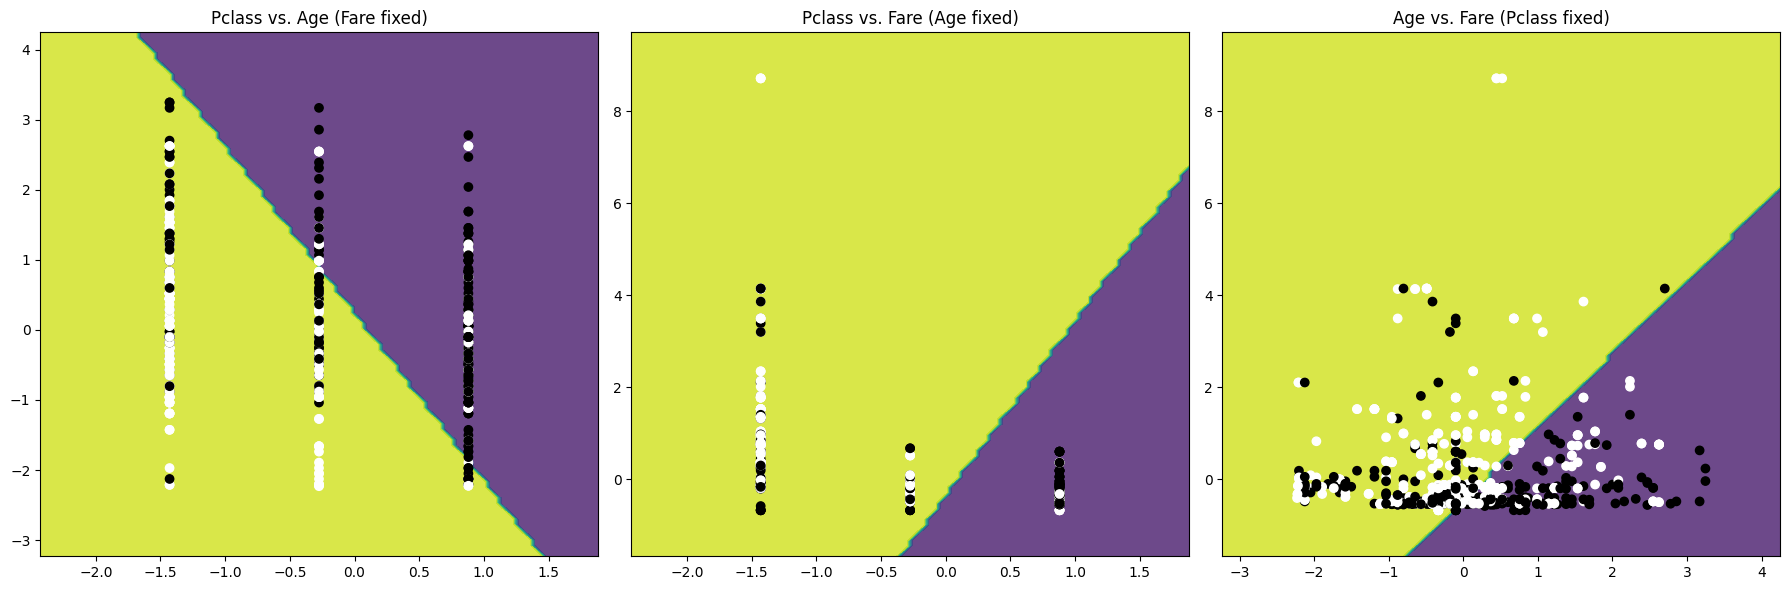

In [ ]:
## Checking the relationship between predictors, fix one, plot the other two vs each other

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Create contour plots for different pairs of features
# Pclass vs. Age
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 100),
                     np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 100))
fare_median = X_train[:, 2].mean()  # Fix Fare to median
Z = model.predict(np.c_[xx.ravel(), yy.ravel(), np.full_like(xx.ravel(), fare_median)])
Z = Z.reshape(xx.shape)
ax[0].contourf(xx, yy, Z, alpha=0.8)
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='gray')
ax[0].set_title('Pclass vs. Age (Fare fixed)')

# Pclass vs. Fare
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 100),
                     np.linspace(X_train[:, 2].min() - 1, X_train[:, 2].max() + 1, 100))
age_median = X_train[:, 1].mean()  # Fix Age to median
Z = model.predict(np.c_[xx.ravel(), np.full_like(xx.ravel(), age_median), yy.ravel()])
Z = Z.reshape(xx.shape)
ax[1].contourf(xx, yy, Z, alpha=0.8)
ax[1].scatter(X_train[:, 0], X_train[:, 2], c=y_train, cmap='gray')
ax[1].set_title('Pclass vs. Fare (Age fixed)')

# Age vs. Fare
xx, yy = np.meshgrid(np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 100),
                     np.linspace(X_train[:, 2].min() - 1, X_train[:, 2].max() + 1, 100))
pclass_median = X_train[:, 0].mean()  # Fix Pclass to median
Z = model.predict(np.c_[np.full_like(xx.ravel(), pclass_median), xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax[2].contourf(xx, yy, Z, alpha=0.8)
ax[2].scatter(X_train[:, 1], X_train[:, 2], c=y_train, cmap='gray')
ax[2].set_title('Age vs. Fare (Pclass fixed)')

plt.tight_layout()
plt.show()
